In [1]:
from urielplus.urielplus import URIELPlus

u_pre = URIELPlus()          
u_pre.integrate_bdproto()
u_pre.integrate_apics()
u_pre.integrate_saphon()
u_pre.integrate_ewave()
u_pre.integrate_grambank()

u_pre.set_aggregation('U')
u_pre.aggregate()

2026-05-13 23:11:13,369 - root - INFO - Importing BDPROTO from "bdproto_data.csv"....


2026-05-13 23:11:13,371 - root - INFO - Converting ISO 639-3 codes to Glottocodes....


2026-05-13 23:11:13,610 - root - INFO - Conversion to Glottocodes complete.


2026-05-13 23:11:31,078 - root - INFO - BDPROTO integration complete.


2026-05-13 23:11:31,081 - root - INFO - Importing APiCS from "apics_data.csv"....


...

2026-05-13 23:12:03,015 - root - INFO - Executing new BFS-based genetic imputation strategy...


2026-05-13 23:12:09,136 - root - INFO - Found 3019 root languages for genetic imputation.


2026-05-13 23:12:09,150 - root - INFO - Genetic imputation finished.


2026-05-13 23:12:09,177 - root - INFO - Aggregation complete for idx=1.


array([[[-1.],
        [-1.],
        [-1.],
        ...,
        [-1.],
        [-1.],
        [-1.]],

       [[-1.],
        [-1.],
        [-1.],
        ...,
        [-1.],
        [-1.],
        [-1.]],

       [[-1.],
        [-1.],
        [-1.],
        ...,
        [-1.],
        [-1.],
        [-1.]],

       ...,

       [[-1.],
        [-1.],
        [-1.],
        ...,
        [ 0.],
        [ 0.],
        [ 1.]],

       [[ 0.],
        [ 1.],
        [ 0.],
        ...,
        [ 0.],
        [ 0.],
        [ 0.]],

       [[-1.],
        [-1.],
        [-1.],
        ...,
        [ 0.],
        [ 0.],
        [ 0.]]], shape=(8171, 800, 1))

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from pathlib import Path

from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import LabelEncoder

try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False

try:
    from fancyimpute import SoftImpute
    HAS_SOFTIMPUTE = True
except ImportError:
    HAS_SOFTIMPUTE = False

OUTDIR = Path("urielplus_analysis")
OUTDIR.mkdir(exist_ok=True)

sns.set_style("whitegrid")

# URIEL+ Typological Data Empirical Missingness Data Analysis 
Sections:
1. Load data, build DataFrame, export CSV
2. All factors that contribute to missingness
3. All factors that help infer a missing value
4. SoftImpute diagnosis — where it works and where it breaks

(1) Build dataframe as well as the csv file

In [3]:
X_raw = u_pre.data[1].squeeze()

X = X_raw.astype(np.float64).copy()
X[X == -1] = np.nan

df_typ = pd.DataFrame(
    X,
    index=u_pre.langs[1],
    columns=u_pre.feats[1]
)

print("DataFrame shape:", df_typ.shape)

csv_path = OUTDIR / "typological_data.csv"

df_typ.index.name = "language"
df_typ.to_csv(csv_path)

print(f"CSV saved to: {csv_path}")

DataFrame shape: (8171, 800)


CSV saved to: urielplus_analysis/typological_data.csv


(2) EDA: \
We try to find factors that might contribute to missingness, and according to how the URIEL+ is organized initially, we look at from 3 angles: (a) database membership (b) language features (c) typological features

(a) Database Membership

In [4]:
from urielplus.urielplus import URIELPlus

def build_single_db(db_name):

    u = URIELPlus()

    if db_name == "BDProto":
        u.integrate_bdproto()

    elif db_name == "APiCS":
        u.integrate_apics()

    elif db_name == "Saphon":
        u.integrate_saphon()

    elif db_name == "eWAVE":
        u.integrate_ewave()

    elif db_name == "Grambank":
        u.integrate_grambank()

    else:
        raise ValueError(f"Unknown database: {db_name}")

    u.set_aggregation("U")
    u.aggregate()

    return u


u_bd  = build_single_db("BDProto")
u_ap  = build_single_db("APiCS")
u_sa  = build_single_db("Saphon")
u_ew  = build_single_db("eWAVE")
u_gb  = build_single_db("Grambank")

2026-05-13 23:12:12,550 - root - INFO - Importing BDPROTO from "bdproto_data.csv"....


2026-05-13 23:12:12,551 - root - INFO - Converting ISO 639-3 codes to Glottocodes....


2026-05-13 23:12:12,833 - root - INFO - Conversion to Glottocodes complete.


2026-05-13 23:12:29,882 - root - INFO - BDPROTO integration complete.


2026-05-13 23:12:29,885 - root - INFO - Creating union of data across sources....


...

2026-05-13 23:13:26,967 - root - INFO - Creating union of data across sources....


2026-05-13 23:13:27,046 - root - INFO - Executing new BFS-based genetic imputation strategy...


2026-05-13 23:13:33,183 - root - INFO - Found 2977 root languages for genetic imputation.


2026-05-13 23:13:33,204 - root - INFO - Genetic imputation finished.


2026-05-13 23:13:33,220 - root - INFO - Aggregation complete for idx=1.


In [5]:
db_objects = {
    "BDProto":  u_bd,
    "APiCS":    u_ap,
    "Saphon":   u_sa,
    "eWAVE":    u_ew,
    "Grambank": u_gb
}

db_languages = {}
db_features  = {}

for db_name, u in db_objects.items():

    db_languages[db_name] = set(u.langs[1])

    db_features[db_name] = set(u.feats[1])

print("Languages per Database:")
for k, v in db_languages.items():
    print(f"{k:10s}: {len(v)}")

print("\nFeatures per Database:")
for k, v in db_features.items():
    print(f"{k:10s}: {len(v)}")

Languages per Database:
BDProto   : 7989
APiCS     : 7830
Saphon    : 7970
eWAVE     : 7868
Grambank  : 7951

Features per Database:
BDProto   : 289
APiCS     : 431
Saphon    : 289
eWAVE     : 529
Grambank  : 458


In [6]:
db_membership = pd.DataFrame(index=df_typ.index)

for db_name, langs in db_languages.items():

    db_membership[db_name] = [
        int(lang in langs)
        for lang in df_typ.index
    ]

db_membership["n_databases"] = (
    db_membership.sum(axis=1)
)

db_membership["miss_rate"] = (
    df_typ.isna().mean(axis=1)
)


Figure 1: the histogram of how many databases each language appears in

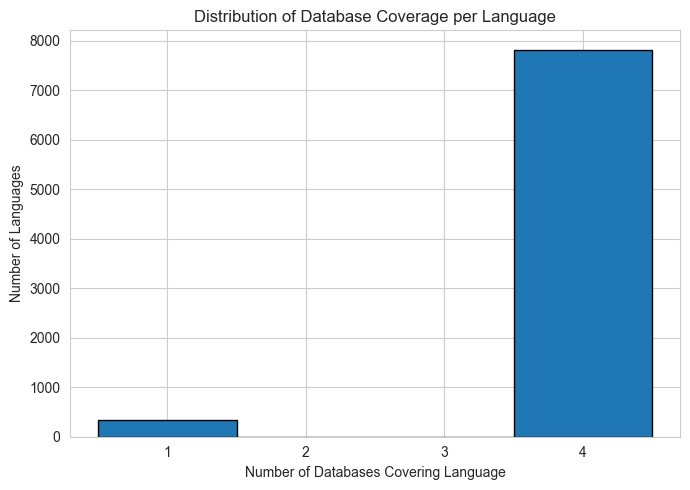

In [7]:
plt.figure(figsize=(7, 5))

bins = np.arange(
    db_membership["n_databases"].min(),
    db_membership["n_databases"].max() + 2
) - 0.5

plt.hist(
    db_membership["n_databases"],
    bins=bins,
    edgecolor="black"
)

plt.xticks(range(
    int(db_membership["n_databases"].min()),
    int(db_membership["n_databases"].max()) + 1
))

plt.xlabel("Number of Databases Covering Language")
plt.ylabel("Number of Languages")
plt.title("Distribution of Database Coverage per Language")

plt.tight_layout()
plt.show()

Figure 2: feature coverage and database membership

2026-05-13 23:13:33,576 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-13 23:13:33,598 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


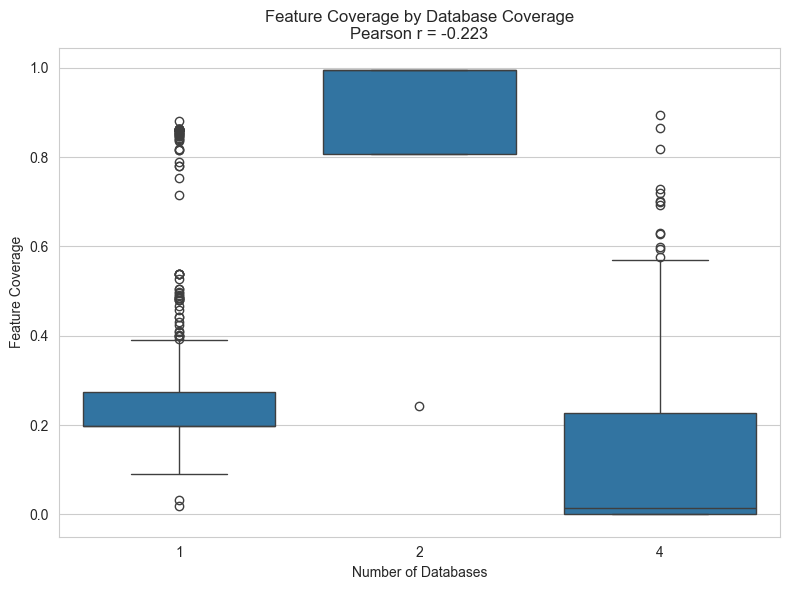

In [8]:
db_membership["n_observed_features"] = (
    df_typ.notna().sum(axis=1)
)

db_membership["total_features"] = df_typ.shape[1]
db_membership["feature_coverage"] = (
    db_membership["n_observed_features"]
    / db_membership["total_features"]
)

db_membership["miss_rate"] = (
    1 - db_membership["feature_coverage"]
)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=db_membership,
    x="n_databases",
    y="feature_coverage"
)


corr_fc = db_membership[
    ["n_databases", "feature_coverage"]
].corr().iloc[0, 1]

plt.title(
    f"Feature Coverage by Database Coverage\nPearson r = {corr_fc:.3f}"
)

plt.xlabel("Number of Databases")
plt.ylabel("Feature Coverage")

plt.tight_layout()
plt.show()


Exclusive languages (languages that are only covered by one database)

In [9]:

exclusive_langs = db_membership[
    db_membership["n_databases"] == 1
].copy()

multi_langs = db_membership[
    db_membership["n_databases"] > 1
].copy()

print("Exclusive languages:", len(exclusive_langs))
print("Multi-database languages:", len(multi_langs))

print("\nAverage missingness")
print(
    f"Exclusive: {exclusive_langs['miss_rate'].mean():.3f}"
)
print(
    f"Multi-DataBase : {multi_langs['miss_rate'].mean():.3f}"
)

Exclusive languages: 346
Multi-database languages: 7825

Average missingness
Exclusive: 0.694
Multi-DataBase : 0.874


Figure 3: exclusive language counts per database

BDProto     167
Grambank    129
eWAVE        44
APiCS         6
Name: count, dtype: int64


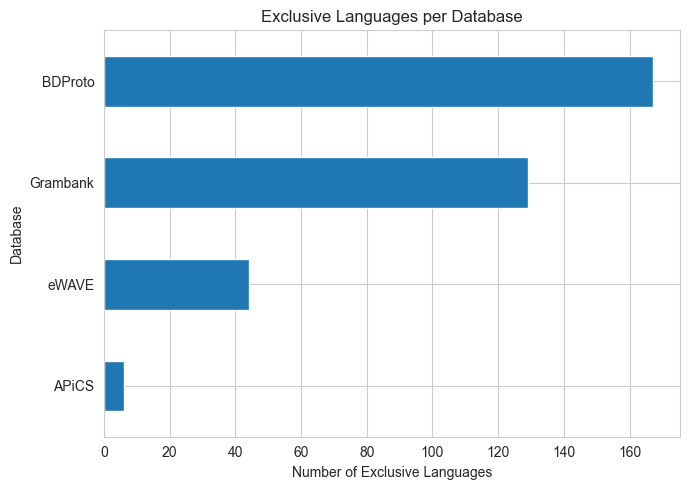

In [10]:
db_names = list(db_languages.keys())

exclusive_db = []

for lang in exclusive_langs.index:

    row = db_membership.loc[lang, db_names]

    owning_db = row[row == 1].index[0]

    exclusive_db.append(owning_db)

exclusive_counts = pd.Series(exclusive_db).value_counts()

print(exclusive_counts)

plt.figure(figsize=(7, 5))

exclusive_counts.sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of Exclusive Languages")
plt.ylabel("Database")
plt.title("Exclusive Languages per Database")

plt.tight_layout()
plt.show()

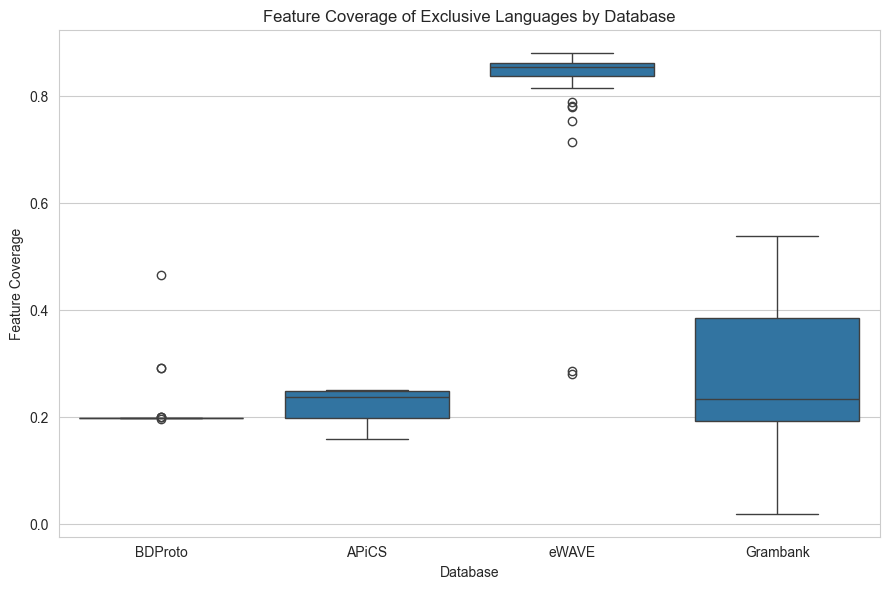

In [11]:
exclusive_rows = []

for lang in exclusive_langs.index:

    row = db_membership.loc[lang, db_names]

    owning_db = row[row == 1].index[0]

    exclusive_rows.append({
        "language": lang,
        "database": owning_db,
        "feature_coverage": db_membership.loc[
            lang, "feature_coverage"
        ],
        "miss_rate": db_membership.loc[
            lang, "miss_rate"
        ]
    })

exclusive_df = pd.DataFrame(exclusive_rows)

exclusive_stats = (
    exclusive_df
    .groupby("database")["feature_coverage"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .sort_values("mean")
)

exclusive_stats

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=exclusive_df,
    x="database",
    y="feature_coverage"
)

plt.xlabel("Database")
plt.ylabel("Feature Coverage")
plt.title("Feature Coverage of Exclusive Languages by Database")

plt.tight_layout()
plt.show()

In [12]:
db_membership.head()

,BDProto,APiCS,Saphon,eWAVE,Grambank,n_databases,miss_rate,n_observed_features,total_features,feature_coverage
language,,,,,,,,,,
ghot1243,1,1,0,1,1,4,1.0,0,800,0.0
alum1246,1,1,0,1,1,4,1.0,0,800,0.0
arii1243,1,1,0,1,1,4,1.0,0,800,0.0
amal1242,1,1,0,1,1,4,1.0,0,800,0.0
arbe1236,1,1,0,1,1,4,1.0,0,800,0.0


(b) Language Features
1. What does the distribution of per-language feature coverage look like?
2. Does missingness cluster by language family?
3. Does missingness cluster by macroarea (Glottolog geographic zone)?
4. Does missingness cluster by resource level** ?
 
We use Glottolog codes (already in `df_typ.index`) to pull family and
macroarea from Glottolog's published CLDF dataset, and ISO 639-3 codes to
join the Joshi resource-level classification.

Figure 4: histogram of feature coverage per language

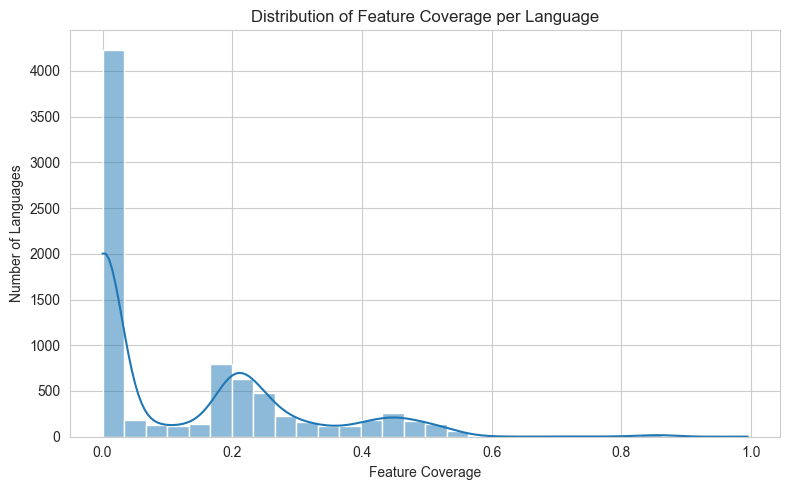

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    db_membership["feature_coverage"],
    bins=30,
    kde=True
)

plt.xlabel("Feature Coverage")
plt.ylabel("Number of Languages")
plt.title("Distribution of Feature Coverage per Language")

plt.tight_layout()
plt.show()

build per language metadata frame with family, macroarea and ISO (language.csv from https://github.com/glottolog/glottolog-cldf/blob/master/cldf/languages.csv)

In [14]:
glotto_df = pd.read_csv('languages.csv')
glotto_meta = (
    glotto_df[
        [
            "ID",
            "Name",
            "Macroarea",
            "Family_ID",
            "ISO639P3code"
        ]
    ]
    .rename(columns={
        "ID"           : "glottocode",
        "Name"         : "glotto_name",
        "Macroarea"    : "macroarea",
        "Family_ID"    : "family_id",
        "ISO639P3code" : "iso639_3",
    })
)

print(glotto_meta.shape)

glotto_meta.head()

(27177, 5)


,glottocode,glotto_name,macroarea,family_id,iso639_3
0,abkh1242,Abkhaz-Adyge,Eurasia,NaN,NaN
1,surm1244,Surmic,Africa,NaN,NaN
2,tama1329,Tamaic,Africa,NaN,NaN
3,yare1250,Yareban,Papunesia,NaN,NaN
4,monu1249,Bogia,Papunesia,NaN,NaN


In [15]:
db_membership = db_membership.reset_index()

db_membership = db_membership.rename(
    columns={"language": "glottocode"}
)

# Left join:
# keep all URIEL+ languages even if metadata missing
db_membership = db_membership.merge(
    glotto_meta,
    on="glottocode",
    how="left"
)

# Restore glottocode as index
db_membership = db_membership.set_index("glottocode")

print("Merged shape:", db_membership.shape)

db_membership.head()


Merged shape: (8171, 14)


,BDProto,APiCS,Saphon,eWAVE,Grambank,n_databases,miss_rate,n_observed_features,total_features,feature_coverage,glotto_name,macroarea,family_id,iso639_3
glottocode,,,,,,,,,,,,,,
ghot1243,1,1,0,1,1,4,1.0,0,800,0.0,Ghotuo,Africa,atla1278,aaa
alum1246,1,1,0,1,1,4,1.0,0,800,0.0,Arum,Africa,atla1278,aab
arii1243,1,1,0,1,1,4,1.0,0,800,0.0,Ari,Papunesia,suki1244,aac
amal1242,1,1,0,1,1,4,1.0,0,800,0.0,Amal,Papunesia,sepi1257,aad
arbe1236,1,1,0,1,1,4,1.0,0,800,0.0,Arbëreshë Albanian,Eurasia,indo1319,aae


In [16]:
matched = db_membership["glotto_name"].notna().sum()

total = len(db_membership)

print(f"Matched languages: {matched}/{total}")
print(f"Coverage: {matched/total:.3f}")

Matched languages: 8169/8171
Coverage: 1.000


Macroarea analysis

In [17]:
macro_df = db_membership.copy()

macro_df["macroarea_plot"] = (
    macro_df["macroarea"]
    .fillna("Unknown")
)
macro_stats = (
    macro_df
    .groupby("macroarea_plot")["miss_rate"]
    .agg(["mean", "count", "std"])
)

macro_stats["se"] = (
    macro_stats["std"]
    / np.sqrt(macro_stats["count"])
)

macro_stats["ci95"] = (
    1.96 * macro_stats["se"]
)

macro_stats = macro_stats.sort_values("mean")

display(macro_stats)


,mean,count,std,se,ci95
macroarea_plot,,,,,
Africa;Eurasia;South America,0.431250,1,NaN,NaN,NaN
Eurasia;Papunesia,0.507500,1,NaN,NaN,NaN
Australia;Papunesia,0.714375,2,0.122860,0.086875,0.170275
South America,0.763774,570,0.185999,0.007791,0.015270
Africa;Australia;Eurasia;North America;Papunesia;South America,0.801250,2,0.000000,0.000000,0.000000
Africa;Eurasia;North America;Papunesia;South America,0.801250,1,NaN,NaN,NaN
Africa;Eurasia;Papunesia;South America,0.801250,2,0.000000,0.000000,0.000000
North America;South America,0.801250,2,0.000000,0.000000,0.000000
Eurasia;North America,0.801250,2,0.000000,0.000000,0.000000


family analysis
(a) Top-20 families ranked by mean miss rate (for family with at least 5 languages, keep the missingness as one categorical unknown); (b) Bottom quartile languages: which families are over-represented?

In [18]:
family_df = db_membership.copy()

family_df["family_plot"] = (
    family_df["family_id"]
    .fillna("Unknown")
)

print("Number of family categories:",
      family_df["family_plot"].nunique())


Number of family categories: 242


,mean,count,std,se,ci95
family_plot,,,,,
unat1236,1.000000,53,0.000000,0.000000,0.000000
sign1238,0.999101,139,0.004545,0.000385,0.000756
arti1236,0.998594,24,0.006889,0.001406,0.002756
toro1256,0.988558,13,0.041256,0.011442,0.022427
uncl1493,0.985972,36,0.060049,0.010008,0.019616
ramu1234,0.984271,24,0.043715,0.008923,0.017490
geel1240,0.983250,10,0.052968,0.016750,0.032830
spee1234,0.979318,11,0.068594,0.020682,0.040536
book1242,0.979101,185,0.060458,0.004445,0.008712


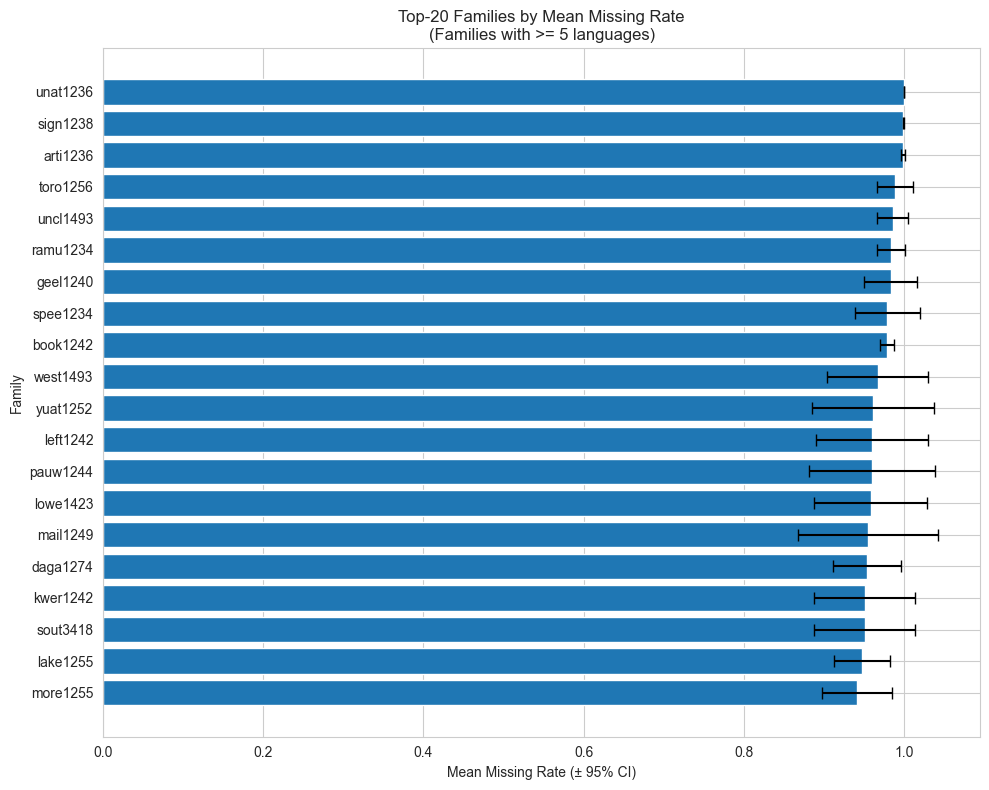

In [19]:
family_stats = (
    family_df
    .groupby("family_plot")["miss_rate"]
    .agg(["mean", "count", "std"])
)

MIN_LANGS = 5

family_stats = family_stats[
    family_stats["count"] >= MIN_LANGS
]

family_stats["se"] = (
    family_stats["std"] / np.sqrt(family_stats["count"])
)
family_stats["ci95"] = 1.96 * family_stats["se"]

family_stats = family_stats.sort_values("mean", ascending=False)

top20_families = family_stats.head(20)

display(top20_families)

fig, ax = plt.subplots(figsize=(10, 8))

y_pos = np.arange(len(top20_families))
ax.barh(
    y_pos,
    top20_families["mean"],
    xerr=top20_families["ci95"],
    capsize=4,
    align="center"
)
ax.set_yticks(y_pos)
ax.set_yticklabels(top20_families.index)
ax.invert_yaxis()

ax.set_xlabel("Mean Missing Rate (± 95% CI)")
ax.set_ylabel("Family")
ax.set_title(
    f"Top-20 Families by Mean Missing Rate\n"
    f"(Families with >= {MIN_LANGS} languages)"
)

plt.tight_layout()
plt.show()

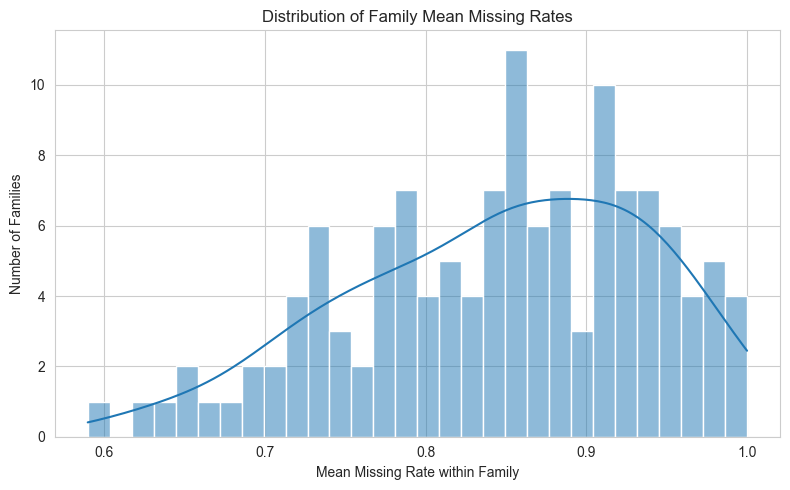

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    family_stats["mean"],
    bins=30,
    kde=True
)

plt.xlabel("Mean Missing Rate within Family")
plt.ylabel("Number of Families")

plt.title(
    "Distribution of Family Mean Missing Rates"
)

plt.tight_layout()
plt.show()

Kruskal-Wallis  H = 547.89,  p = 4.84e-104


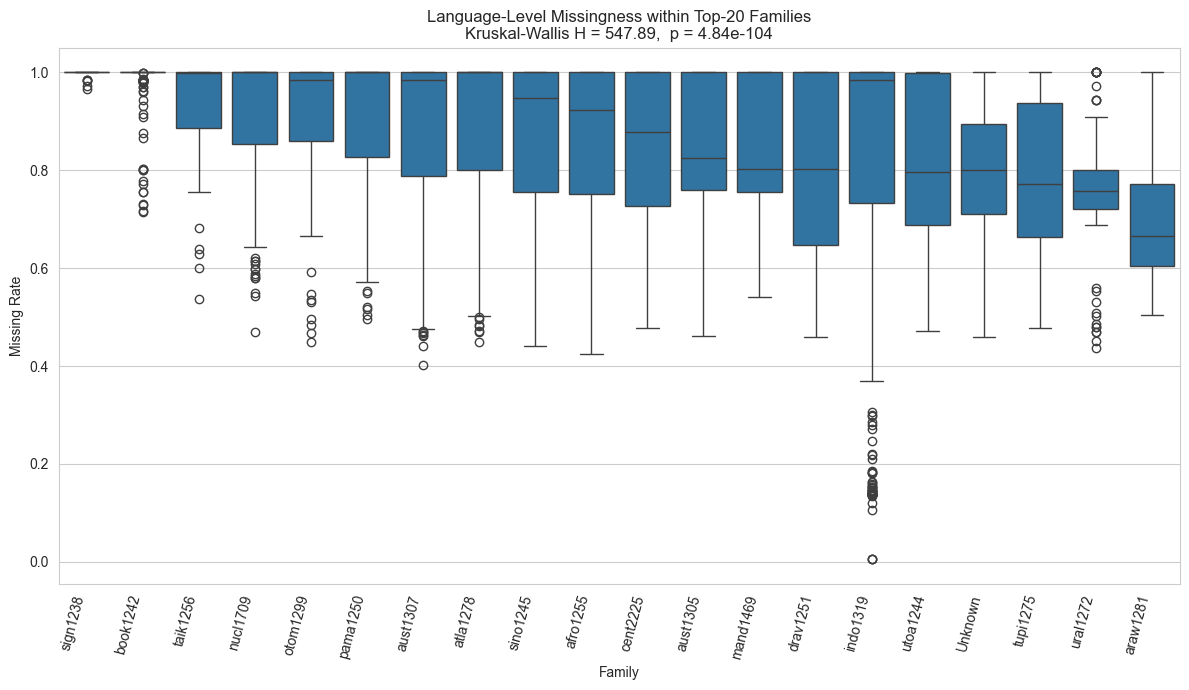

In [21]:
from scipy.stats import kruskal

TOP_N = 20

top_families_by_size = (
    family_df["family_plot"]
    .value_counts()
    .head(TOP_N)
    .index
)

plot_df = family_df[
    family_df["family_plot"].isin(top_families_by_size)
].copy()

groups = [
    plot_df.loc[
        plot_df["family_plot"] == fam, "miss_rate"
    ].values
    for fam in top_families_by_size
]
stat, p_val = kruskal(*groups)
print(f"Kruskal-Wallis  H = {stat:.2f},  p = {p_val:.2e}")

family_order = (
    plot_df
    .groupby("family_plot")["miss_rate"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=plot_df,
    x="family_plot",
    y="miss_rate",
    order=family_order
)

plt.xticks(rotation=75, ha="right")
plt.xlabel("Family")
plt.ylabel("Missing Rate")
plt.title(
    f"Language-Level Missingness within Top-{TOP_N} Families\n"
    f"Kruskal-Wallis H = {stat:.2f},  p = {p_val:.2e}"
)

plt.tight_layout()
plt.show()

Bottom-quartile threshold: coverage ≤ 0.000
Languages in bottom quartile: 3615


,n_bottom_q,n_total,pct_in_bottom_q,over_rep_ratio
family_clean,,,,
unat1236,53.0,53,1.000,2.260
arti1236,23.0,24,0.958,2.166
sign1238,133.0,139,0.957,2.163
uncl1493,34.0,36,0.944,2.135
toro1256,12.0,13,0.923,2.086
spee1234,10.0,11,0.909,2.055
geel1240,9.0,10,0.900,2.034
yeni1252,5.0,6,0.833,1.884
mail1249,5.0,6,0.833,1.884


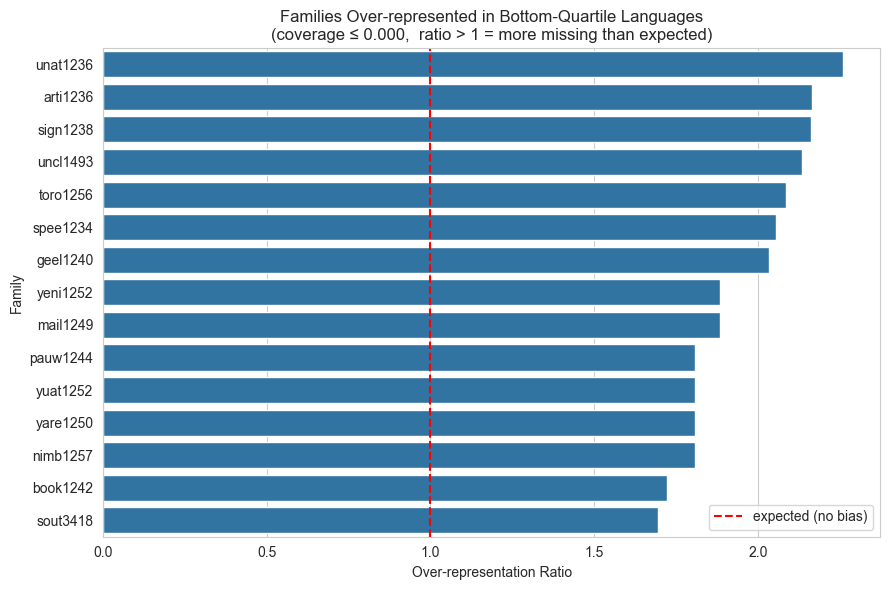

In [22]:
# (b) Bottom-quartile: which families are over-represented
#     among languages with feature_coverage in the bottom 25%?

q25 = db_membership["feature_coverage"].quantile(0.25)
bottom_q = db_membership[
    db_membership["feature_coverage"] <= q25
].copy()

bottom_q["family_clean"] = bottom_q["family_id"].fillna("isolate/unknown")
family_df["family_clean"] = family_df["family_plot"]

eligible = family_stats.index  # families with >= MIN_LANGS

bottom_counts = (
    bottom_q[bottom_q["family_clean"].isin(eligible)]
    ["family_clean"].value_counts()
)
all_counts = (
    family_df[family_df["family_clean"].isin(eligible)]
    ["family_clean"].value_counts()
)

over_rep = pd.DataFrame({
    "n_bottom_q": bottom_counts,
    "n_total":    all_counts,
}).dropna()

over_rep["pct_in_bottom_q"] = (
    over_rep["n_bottom_q"] / over_rep["n_total"]
)
expected = len(bottom_q) / len(db_membership)
over_rep["over_rep_ratio"] = (
    over_rep["pct_in_bottom_q"] / expected
)
over_rep = over_rep.sort_values("over_rep_ratio", ascending=False)

print(f"Bottom-quartile threshold: coverage \u2264 {q25:.3f}")
print(f"Languages in bottom quartile: {len(bottom_q)}")
display(over_rep.head(15).round(3))

plt.figure(figsize=(9, 6))
sns.barplot(
    x=over_rep.head(15)["over_rep_ratio"],
    y=over_rep.head(15).index
)
plt.axvline(1.0, color="red", ls="--", label="expected (no bias)")
plt.xlabel("Over-representation Ratio")
plt.ylabel("Family")
plt.title(
    "Families Over-represented in Bottom-Quartile Languages\n"
    f"(coverage \u2264 {q25:.3f},  ratio > 1 = more missing than expected)"
)
plt.legend()
plt.tight_layout()
plt.show()

Resource Level (distals \u2014 Joshi 2020 NLP State, Wikipedia size, Speaker count, AES endangerment)

Join via ISO 639-3 codes already present in `db_membership`. Four analyses:
1. **NLP State** (0 Left-Behinds \u2192 5 Winners): does higher NLP resource level \u2192 lower miss rate?
2. **Wikipedia size** (log): continuous proxy for documentation effort
3. **Speaker count** (log): larger speech communities tend to be better documented
4. **AES endangerment** (0 extinct \u2192 5 not endangered): does language vitality predict coverage?

In [23]:
import gzip, pickle

# Load distals DB (ISO 639-3 keyed) and extract resource-level fields
db_path = "distals/distals-db.pickle.gz"
with gzip.open(db_path, "rb") as f:
    distals_db = pickle.load(f)

resource_rows = []
for iso, info in distals_db.items():
    resource_rows.append({
        "iso639_3": iso,
        "nlp_state": info.get("nlp_state"),
        "wiki_size": info.get("wiki_size"),
        "speakers":  info.get("speakers"),
        "AES":       info.get("AES"),
    })
resource_df = pd.DataFrame(resource_rows)

# Join to db_membership via iso639_3 (present after glottolog merge)
resource_miss = (
    db_membership
    .reset_index()
    .merge(resource_df, on="iso639_3", how="left")
    .set_index("glottocode")
)

print("resource_miss shape:", resource_miss.shape)
print("\nDistals field coverage (matched to URIEL+ languages):")
for col in ["nlp_state", "wiki_size", "speakers", "AES"]:
    n = resource_miss[col].notna().sum()
    print(f"  {col:12s}: {n:5d} / {len(resource_miss)} "
          f"({n / len(resource_miss) * 100:.1f}%)")

resource_miss shape: (8171, 18)

Distals field coverage (matched to URIEL+ languages):
  nlp_state   :  2260 / 8171 (27.7%)
  wiki_size   :  7626 / 8171 (93.3%)
  speakers    :  5470 / 8171 (66.9%)
  AES         :  7586 / 8171 (92.8%)


In [ ]:
from scipy.stats import spearmanr

nlp_order = [
    "0. The Left-Behinds",
    "1. The Scraping-Bys",
    "2. The Hopefuls",
    "3. The Rising Stars",
    "4. The Underdogs",
    "5. The Winners",
]

nlp_data = resource_miss.dropna(subset=["nlp_state"]).copy()
nlp_data["nlp_state"] = pd.Categorical(
    nlp_data["nlp_state"], categories=nlp_order, ordered=True
)

nlp_stats = (
    nlp_data.groupby("nlp_state", observed=True)["miss_rate"]
    .agg(["mean", "count", "std"])
)
nlp_stats["se"] = nlp_stats["std"] / np.sqrt(nlp_stats["count"])
print(f"Languages with nlp_state: {len(nlp_data)}")
display(nlp_stats.round(3))

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=nlp_data, x="nlp_state", y="miss_rate",
    order=nlp_order
)
plt.xticks(
    range(len(nlp_order)),
    [s.split(". ")[1] for s in nlp_order],
    rotation=30, ha="right"
)
plt.xlabel("NLP Resource Level")
plt.ylabel("Missing Rate")
plt.title(f"Missingness by NLP State  (N={len(nlp_data)})")
plt.tight_layout()
plt.show()

nlp_data["nlp_num"] = nlp_data["nlp_state"].cat.codes
rho, pval = spearmanr(nlp_data["nlp_num"], nlp_data["miss_rate"])
print(f"\nSpearman \u03c1 (nlp_state vs miss_rate) = {rho:.3f},  p = {pval:.2e}")

In [ ]:
nlp_counts = nlp_data["nlp_state"].value_counts().reindex(nlp_order)

plt.figure(figsize=(8, 5))
plt.bar(range(len(nlp_order)), nlp_counts.values)
plt.xticks(
    range(len(nlp_order)),
    [s.split(". ")[1] for s in nlp_order],
    rotation=30, ha="right"
)
plt.ylabel("Number of Languages")
plt.title("Language Count per NLP State")
plt.tight_layout()
plt.show()

In [ ]:
wiki_data = resource_miss[resource_miss["wiki_size"] > 0].copy()
wiki_data["log_wiki"] = np.log1p(wiki_data["wiki_size"])

wiki_data["wiki_bin"] = pd.qcut(
    wiki_data["log_wiki"], q=5,
    labels=["Q1 (smallest)", "Q2", "Q3", "Q4", "Q5 (largest)"]
)

plt.figure(figsize=(8, 5))
plt.scatter(
    wiki_data["log_wiki"], wiki_data["miss_rate"],
    alpha=0.2, s=5
)
plt.xlabel("log(1 + Wikipedia size)")
plt.ylabel("Missing Rate")
plt.title(
    f"Wikipedia Size vs Missingness  (N={len(wiki_data)} with wiki > 0)"
)
plt.tight_layout()
plt.show()

rho2, pval2 = spearmanr(wiki_data["log_wiki"], wiki_data["miss_rate"])
print(f"Spearman \u03c1 (log_wiki_size vs miss_rate) = {rho2:.3f},  p = {pval2:.2e}")

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=wiki_data, x="wiki_bin", y="miss_rate"
)
plt.xlabel("Wikipedia Size Quintile")
plt.ylabel("Missing Rate")
plt.title("Missingness by Wikipedia Size Quintile")
plt.tight_layout()
plt.show()

In [ ]:
spk_data = resource_miss.dropna(subset=["speakers"]).copy()
spk_data = spk_data[spk_data["speakers"] > 0]
spk_data["log_speakers"] = np.log1p(spk_data["speakers"])

spk_data["spk_bin"] = pd.qcut(
    spk_data["log_speakers"], q=5,
    labels=["Q1 (<1k)", "Q2", "Q3", "Q4", "Q5 (>1M)"]
)

plt.figure(figsize=(8, 5))
plt.scatter(
    spk_data["log_speakers"], spk_data["miss_rate"],
    alpha=0.2, s=5
)
plt.xlabel("log(1 + speakers)")
plt.ylabel("Missing Rate")
plt.title(f"Speaker Count vs Missingness  (N={len(spk_data)})")
plt.tight_layout()
plt.show()

rho3, pval3 = spearmanr(spk_data["log_speakers"], spk_data["miss_rate"])
print(f"Spearman \u03c1 (log_speakers vs miss_rate) = {rho3:.3f},  p = {pval3:.2e}")

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=spk_data, x="spk_bin", y="miss_rate"
)
plt.xlabel("Speaker Count Quintile")
plt.ylabel("Missing Rate")
plt.title("Missingness by Speaker Count Quintile")
plt.tight_layout()
plt.show()

In [ ]:
aes_order = [
    "0. extinct",
    "1. nearly extinct",
    "2. moribund",
    "3. shifting",
    "4. threatened",
    "5. not endangered",
]

aes_data = resource_miss.dropna(subset=["AES"]).copy()
aes_data["AES"] = pd.Categorical(
    aes_data["AES"], categories=aes_order, ordered=True
)

aes_stats = (
    aes_data.groupby("AES", observed=True)["miss_rate"]
    .agg(["mean", "count", "std"])
)
print(f"Languages with AES: {len(aes_data)}")
display(aes_stats.round(3))

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=aes_data, x="AES", y="miss_rate",
    order=aes_order
)
plt.xticks(
    range(len(aes_order)),
    [s.split(". ")[1] for s in aes_order],
    rotation=30, ha="right"
)
plt.xlabel("Endangerment Status (AES)")
plt.ylabel("Missing Rate")
plt.title(
    f"Missingness by AES Endangerment Status  (N={len(aes_data)})"
)
plt.tight_layout()
plt.show()

aes_data["aes_num"] = aes_data["AES"].cat.codes
rho4, pval4 = spearmanr(aes_data["aes_num"], aes_data["miss_rate"])
print(f"\nSpearman \u03c1 (AES_code vs miss_rate) = {rho4:.3f},  p = {pval4:.2e}")

In [ ]:
aes_counts = aes_data["AES"].value_counts().reindex(aes_order)

plt.figure(figsize=(8, 5))
plt.bar(range(len(aes_order)), aes_counts.values)
plt.xticks(
    range(len(aes_order)),
    [s.split(". ")[1] for s in aes_order],
    rotation=30, ha="right"
)
plt.ylabel("Number of Languages")
plt.title("Language Count per AES Status")
plt.tight_layout()
plt.show()

(c) feature 
1. Which individual features are most/least covered?
2. Do the four feature-type prefixes (S_, P_, M_, I_) differ in coverage?
3. Within each prefix, which sub-groups drive the missingness?
4. Is there a block-diagonal missingness structure tied to Database origin?
5. Are certain features correlated in their missingness (missing together
   for reasons beyond mere database overlap)?

In [28]:
def infer_modality(feature):

    if feature.startswith("S_"):
        return "syntax"

    elif feature.startswith("P_"):
        return "phonology"

    elif feature.startswith("M_"):
        return "morphology"

    elif feature.startswith("INV_"):
        return "inventory"

    else:
        return "other"


feat_meta = pd.DataFrame({
    "feature": df_typ.columns,
    "modality": [infer_modality(f) for f in df_typ.columns],
    "miss_rate": df_typ.isna().mean().values,
    "coverage": df_typ.notna().mean().values,
    "n_present": df_typ.notna().sum().values,
}).set_index("feature")

modality_miss = (
    feat_meta.groupby("modality")["miss_rate"]
    .agg(["mean", "std", "min", "max", "count"])
    .rename(columns={
        "mean": "avg_miss",
        "count": "n_features"
    })
    .sort_values("avg_miss", ascending=False)
)

modality_miss.round(3)


,avg_miss,std,min,max,n_features
modality,,,,,
syntax,0.910,0.116,0.549,0.993,474
phonology,0.867,0.048,0.821,0.992,30
morphology,0.855,0.125,0.697,0.993,133
inventory,0.750,0.045,0.731,0.991,163


,avg_miss,std,min,max,n_features
modality,,,,,
syntax,0.910,0.116,0.549,0.993,474
phonology,0.867,0.048,0.821,0.992,30
morphology,0.855,0.125,0.697,0.993,133
inventory,0.750,0.045,0.731,0.991,163
